### Preprocessing
Create a master csv file with the absolute paths of all the training images.

In [ ]:
import pandas as pd
from pathlib import Path

training_data_path = r"C:\Users\Aravind Kumar\Documents\Osteosarcoma Research\Old Datasets\PKG - Osteosarcoma Tumor Assessment\Training Data"
data_dir = Path(training_data_path)

jpg_files = list(data_dir.rglob("*.jpg")) + list(data_dir.rglob("*.JPG")) + list(data_dir.rglob("*.jpeg"))

path_mapping = pd.DataFrame({
    "image_name_path": [p.name for p in jpg_files],
    "absolute_path": [str(p.resolve()) for p in jpg_files]
})

path_mapping = path_mapping.drop_duplicates(subset="image_name_path", keep="first")
path_mapping["normalized_name"] = path_mapping["image_name_path"].str.replace(r'[\s\-]+', '-', regex=True).str.lower()

ml_features_path = r"C:\Users\Aravind Kumar\Documents\Osteosarcoma Research\Old Datasets\PKG - Osteosarcoma Tumor Assessment\ML_Features_1144.csv"
ml_features = pd.read_csv(ml_features_path)

ml_features["normalized_name"] = ml_features["image.name"].str.replace(r'[\s\-]+', '-', regex=True).str.lower()

mask = ~ml_features["normalized_name"].str.contains(r'\.(jpg|jpeg)$', regex=True)
ml_features.loc[mask, "normalized_name"] = ml_features.loc[mask, "normalized_name"] + ".jpg"

master_dataset = pd.merge(path_mapping, ml_features, on="normalized_name", how="inner")
master_dataset = master_dataset.drop(columns=["normalized_name", "image_name_path"])

master_dataset_path = r"C:\Users\Aravind Kumar\Documents\Osteosarcoma Research\Old Datasets\PKG - Osteosarcoma Tumor Assessment\master_dataset.csv"
master_dataset.to_csv(master_dataset_path, index=False)

print(f"Successfully mapped {len(master_dataset)} unique images.")

Successfully mapped 1144 unique images.


### Checking
Check if the images in the master csv file match with the original image

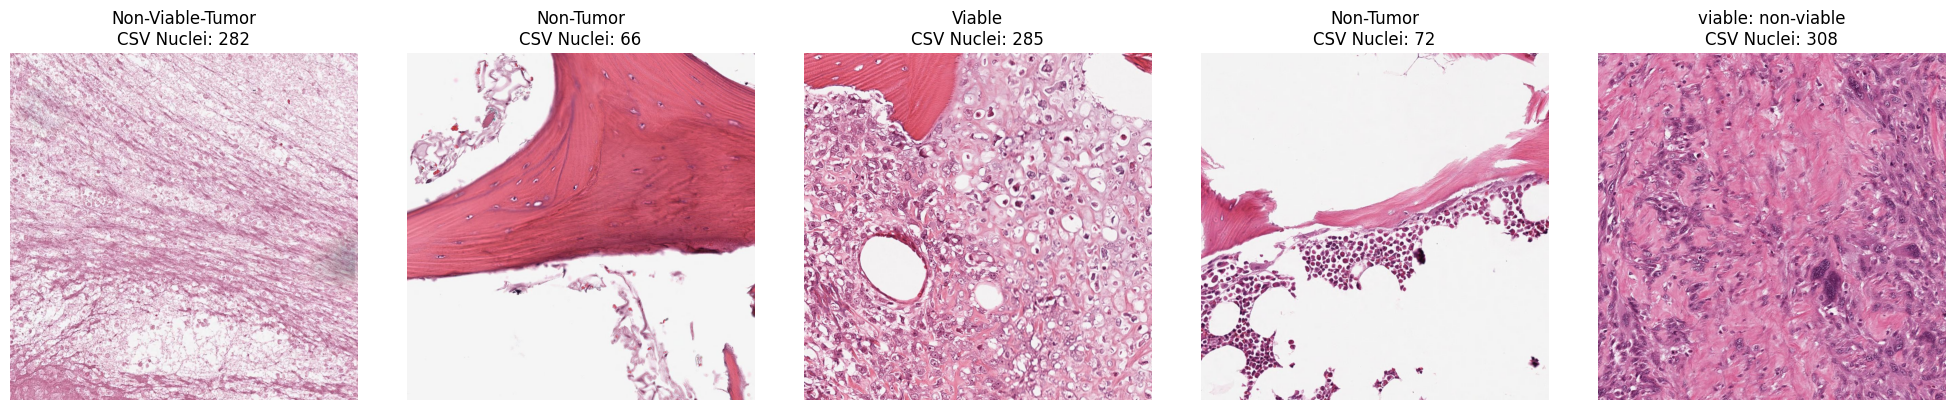

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Load your newly created master dataset
master_dataset_path = r"C:\Users\Aravind Kumar\Documents\Osteosarcoma Research\Old Datasets\PKG - Osteosarcoma Tumor Assessment\master_dataset.csv"
df = pd.read_csv(master_dataset_path)

# Sample 5 random rows
sample_df = df.sample(n=5, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img_path = row['absolute_path']
    label = row['classification']
    nuclei_count = row['Count_Nuclei']
    
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"{label}\nCSV Nuclei: {nuclei_count}")
    ax.axis('off')

plt.tight_layout()
plt.show()